# F_photometry_examples.ipynb

## Purpose

Plot examples sessions of photometry data.

## Manuscript figure panels



## Prerequisites

Before running this notebook, ensure the figure preparation scripts have been run in sequence (see `/root/capsule/code/beh_ephys_analysis/session_combine/figure_preparation/sequence`).

Required input files:
- Per-session photometry data

In [1]:
import numpy as np
import pandas as pd
import sys
from pathlib import Path
# Resolve code/beh_ephys_analysis (the folder containing `utils`) relative to this
# file's location, so imports work no matter where the repo is checked out.
import sys
import os
import pathlib

# Resolve code/beh_ephys_analysis (the folder containing `utils`) relative to this
# file's location, so imports work no matter where the repo is checked out.
try:
    _here = pathlib.Path(__file__).resolve().parent          # script mode
except NameError:
    try:
        _here = pathlib.Path(__vsc_ipynb_file__).resolve().parent  # VS Code notebook
    except NameError:
        _here = pathlib.Path(os.getcwd())                    # other Jupyter fallback

_beh_ephys_root = str((_here / '../..').resolve())
if _beh_ephys_root not in sys.path:
    sys.path.insert(0, _beh_ephys_root)
from utils.ephys_functions import fitSpikeModelG
import platform
import os
from pathlib import Path
import shutil
from utils.beh_functions import session_dirs, get_session_tbl, makeSessionDF
from utils.photometry_utils import get_FP_data, align_signal_to_events, plot_G_vs_Iso
from utils.capsule_migration import capsule_directories
from matplotlib import pyplot as plt
from IPython.display import display
from scipy.signal import find_peaks
from harp.clock import align_timestamps_to_anchor_points
import numpy as np
from scipy.signal import butter, filtfilt, medfilt, sosfiltfilt
from scipy.optimize import curve_fit
import json
from sklearn.linear_model import LinearRegression
from matplotlib.gridspec import GridSpec
import pickle
from joblib import Parallel, delayed
import matplotlib.pyplot as plt
import time

# %matplotlib widget
import re
import random
from matplotlib.gridspec import GridSpec
from utils.photometry_combine import population_GLM, plot_tuning_curve, plot_psth, population_GLM_ani
from contextlib import redirect_stdout
capsule_dirs = capsule_directories()
%matplotlib inline
from utils.capsule_migration import CAPSULE_ROOT
from scipy.stats import zscore
from utils.panel_utils import save_panels, save_panel_csv, columns_to_df, heatmap_to_df

In [2]:
capsule_directories = capsule_directories()
target_dir = os.path.join(capsule_directories['manuscript_fig_dir'], 'FP_examples')

['/root/capsule/scratch/results/manuscript/figures/FP_examples/FigureS17e_power_spectrum.pdf']

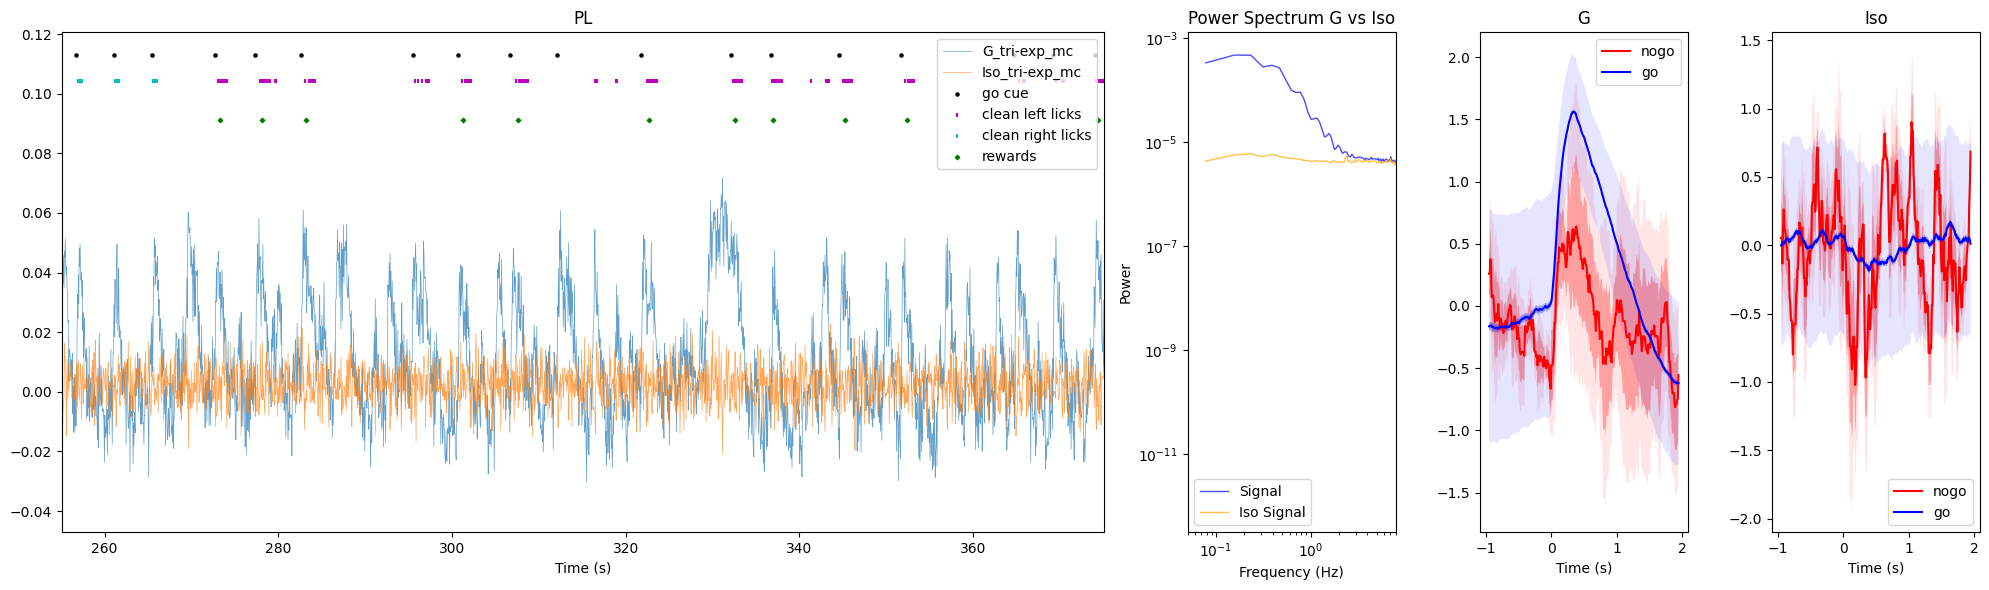

In [3]:
session = 'behavior_754896_2025-01-08_16-03-27'
fig = plot_G_vs_Iso(session, zscore_flag=False, raw_session=True)
##Figure5iright##
##FigureS17f##
##FigureS17e##
save_panels(fig, target_dir, 'example_session_trace', 'Figure5i_right', exts=("pdf",))
save_panels(fig, target_dir, 'example_hit_vs_miss_G_vs_iso', 'FigureS17f', exts=("pdf",))
save_panels(fig, target_dir, 'power_spectrum', 'FigureS17e', exts=("pdf",))

In [ ]:
# Extract data from plot_G_vs_Iso for CSV export (mirrors the function logic)
from scipy.signal import welch
_signal = get_FP_data(session, tar_channels=[('PL', 'G_tri-exp_mc'), ('PL', 'Iso_tri-exp_mc'), ('PL', 'G'), ('PL', 'Iso')])
_session_df = get_session_tbl(session, load_raw=True)
_fs = 20

region = 'PL'
# Figure5i_right: time-series trace (G and Iso, not z-scored to match zscore_flag=False)
trace_df = pd.DataFrame({
    'time': _signal['time_in_beh'],
    'G': _signal['G_tri-exp_mc'][region],
    'Iso': _signal['Iso_tri-exp_mc'][region],
})
save_panel_csv(trace_df, target_dir, f'example_session_trace_{region}', ['Figure5i_right'])

# FigureS17e: power spectrum
_sig_g = _signal['G'][region]; _sig_g = _sig_g[~np.isnan(_sig_g)]
_f_g, _Pxx_g = welch(_sig_g, fs=_fs, window='hann', nperseg=min(256, len(_sig_g)), detrend='constant', scaling='density')
_mask_g = (_f_g > 0) & (_f_g <= 8)
_sig_iso = _signal['Iso'][region]; _sig_iso = _sig_iso[~np.isnan(_sig_iso)]
_f_iso, _Pxx_iso = welch(_sig_iso, fs=_fs, window='hann', nperseg=min(256, len(_sig_iso)), detrend='constant', scaling='density')
_mask_iso = (_f_iso > 0) & (_f_iso <= 8)
psd_df = pd.DataFrame({
    'frequency': _f_g[_mask_g],
    'G_power': _Pxx_g[_mask_g],
    'Iso_power': _Pxx_iso[_mask_iso],
})
save_panel_csv(psd_df, target_dir, f'power_spectrum_{region}', ['FigureS17e'])

# FigureS17f: PSTH G and Iso aligned to go/nogo, with SE
_nogo_times = _session_df.loc[_session_df['animal_response']==2, 'goCue_start_time'].values
_go_times   = _session_df.loc[_session_df['animal_response']!=2, 'goCue_start_time'].values
_g_nogo_mat, _g_nogo_mean, _g_bins, _ = align_signal_to_events(zscore(_signal['G_tri-exp_mc'][region].copy()), _signal['time_in_beh'], _nogo_times)
_g_go_mat,   _g_go_mean,   _g_bins, _ = align_signal_to_events(zscore(_signal['G_tri-exp_mc'][region].copy()), _signal['time_in_beh'], _go_times)
_iso_nogo_mat, _iso_nogo_mean, _iso_bins, _ = align_signal_to_events(zscore(_signal['Iso_tri-exp_mc'][region].copy()), _signal['time_in_beh'], _nogo_times)
_iso_go_mat,   _iso_go_mean,   _iso_bins, _ = align_signal_to_events(zscore(_signal['Iso_tri-exp_mc'][region].copy()), _signal['time_in_beh'], _go_times)
_g_nogo_se   = np.nanstd(_g_nogo_mat,   axis=0) / np.sqrt(np.sum(~np.isnan(_g_nogo_mat),   axis=0))
_g_go_se     = np.nanstd(_g_go_mat,     axis=0) / np.sqrt(np.sum(~np.isnan(_g_go_mat),     axis=0))
_iso_nogo_se = np.nanstd(_iso_nogo_mat, axis=0) / np.sqrt(np.sum(~np.isnan(_iso_nogo_mat), axis=0))
_iso_go_se   = np.nanstd(_iso_go_mat,   axis=0) / np.sqrt(np.sum(~np.isnan(_iso_go_mat),   axis=0))
psth_df = pd.DataFrame({
    'time': _g_bins,
    'G_go_mean': _g_go_mean,
    'G_go_se': _g_go_se,
    'G_nogo_mean': _g_nogo_mean,
    'G_nogo_se': _g_nogo_se,
    'Iso_go_mean': _iso_go_mean,
    'Iso_go_se': _iso_go_se,
    'Iso_nogo_mean': _iso_nogo_mean,
    'Iso_nogo_se': _iso_nogo_se,
})
save_panel_csv(psth_df, target_dir, f'hit_vs_miss_G_vs_iso_{region}', ['FigureS17f'])

['/root/capsule/scratch/results/manuscript/figures/FP_examples/FigureS17f_hit_vs_miss_G_vs_iso_PL.csv']

In [5]:
# ##Figure5iright## Left most panel in fig
##FigureS17f## 2 Right most panel in fig
##FigureS17e## second panel on left in fig